### 1

데이터 형태: (510, 9)

데이터 컬럼: ['TestID', 'Authors', 'h [mm]', 'b1 [mm]', 'fy [MPa]', 'davg [(mm)]', 'ravg', 'f1c [(MPa)]', 'Pu [kN]']

데이터 기본 통계:
           TestID      h [mm]     b1 [mm]    fy [MPa]  davg [(mm)]  \
count  510.000000  510.000000  510.000000  510.000000   510.000000   
mean   256.452941  133.843137  192.674510  463.062745   107.720239   
std    148.864295   67.529539  102.365269  114.150919    60.640272   
min      1.000000   38.000000   51.000000  255.000000    29.972000   
25%    128.250000  100.500000  120.000000  374.500000    78.250000   
50%    255.500000  130.000000  160.000000  462.000000   107.000000   
75%    382.750000  152.000000  250.000000  531.000000   121.000000   
max    519.000000  730.000000  901.000000  749.000000   668.500000   

             ravg  f1c [(MPa)]      Pu [kN]  
count  510.000000   510.000000   510.000000  
mean     0.010982    32.720555   344.447059  
std      0.008230    17.724100   403.105509  
min      0.000000     8.662000    24.000000

c:\Users\yjy98\Documents\Punching-shear\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



그래프가 'ANN_Model_Results.pdf'로 저장되었습니다.


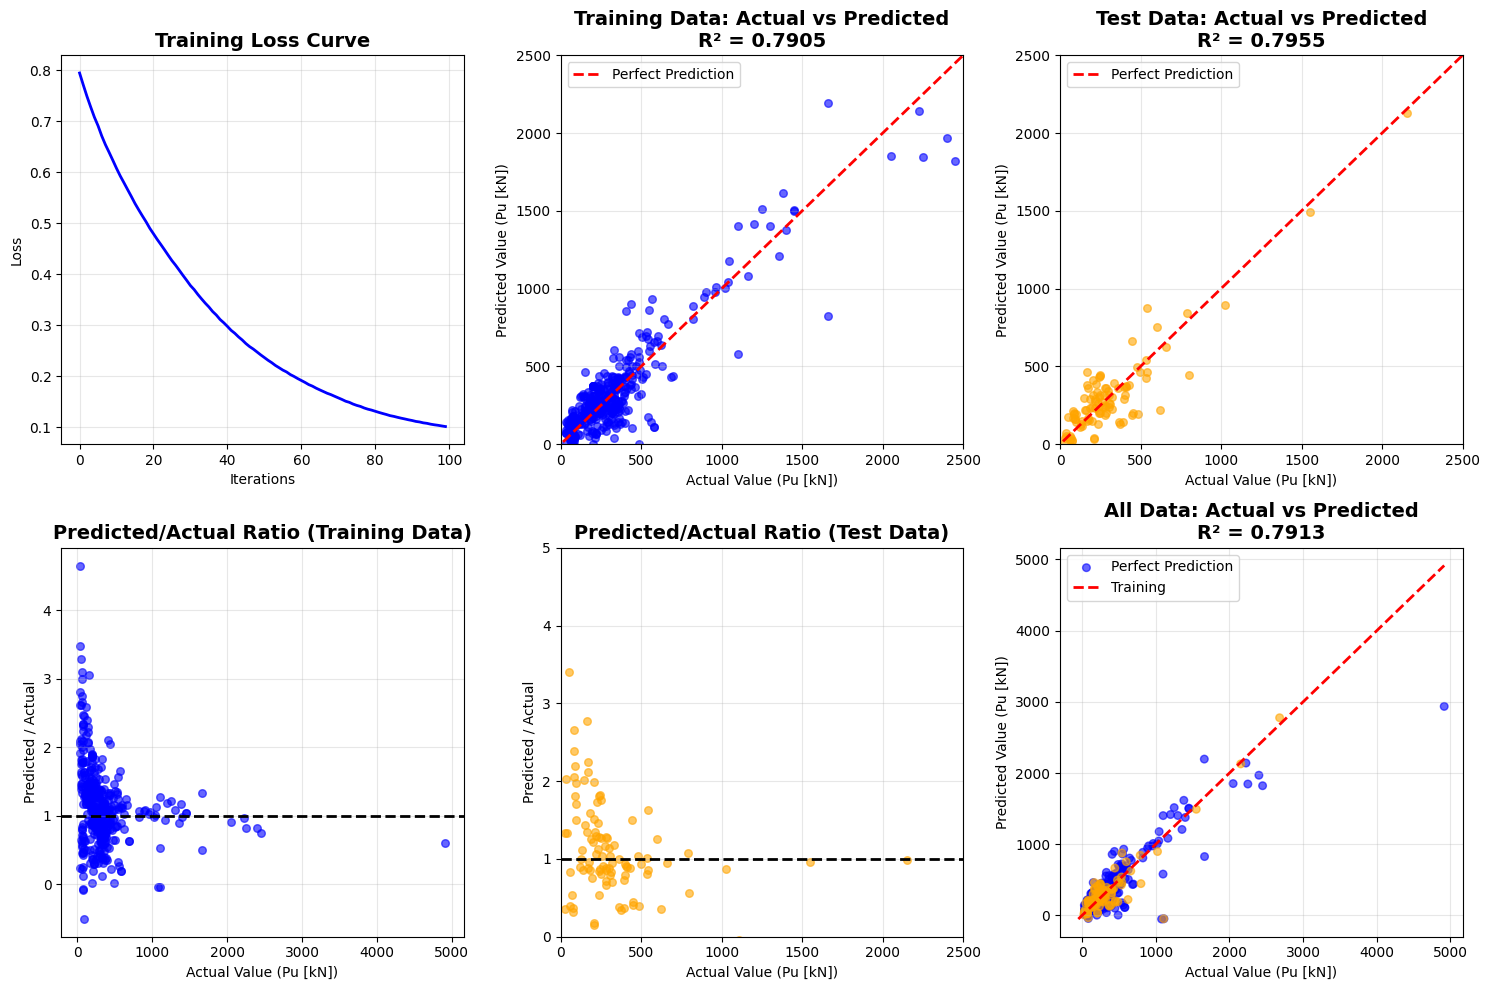


=== 입력 변수별 평균 가중치 크기 ===
h [mm]: 0.2448
b1 [mm]: 0.2631
fy [MPa]: 0.2095
davg [(mm)]: 0.4314
ravg: 0.2739
f1c [(MPa)]: 0.3781

=== 전체 데이터 성능 ===
전체 R²: 0.7913
전체 RMSE: 183.95 kN

모델과 스케일러가 'ann_punching_model.pkl'로 저장되었습니다.

=== 새로운 데이터 예측 예제 ===
입력: h=200mm, b1=300mm, fy=400MPa, davg=180mm, ravg=0.01, f1c=30MPa
예측된 펀칭 전단 강도: 725.12 kN


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
import seaborn as sns
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# Windows의 경우 맑은 고딕 사용 시도
try:
    # Windows 시스템 폰트 경로에서 맑은 고딕 찾기
    font_path = 'C:/Windows/Fonts/malgun.ttf'  # 맑은 고딕
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
except:
    # 맑은 고딕이 없으면 기본 설정 유지하고 영어로 표시
    print("한글 폰트를 찾을 수 없어 영어로 표시됩니다.")

# 데이터 로드
df = pd.read_excel("../데이터 베이스/Tran and Kim (2021).xlsx", sheet_name='NEES_Database__ACI_445_Punching')

# 데이터 확인
print("데이터 형태:", df.shape)
print("\n데이터 컬럼:", df.columns.tolist())
print("\n데이터 기본 통계:")
print(df.describe())

# 입력 변수와 출력 변수 정의
input_features = ['h [mm]', 'b1 [mm]', 'fy [MPa]', 'davg [(mm)]', 'ravg', 'f1c [(MPa)]']
output_feature = 'Pu [kN]'

# 결측값 확인 및 제거
print(f"\n결측값 개수:\n{df[input_features + [output_feature]].isnull().sum()}")
df_clean = df[input_features + [output_feature]].dropna()

# 특성과 타겟 분리
X = df_clean[input_features].values
y = df_clean[output_feature].values

print(f"\n정제된 데이터 개수: {len(X)}개")

# 데이터 분할 (훈련:테스트 = 80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"훈련 데이터: {len(X_train)}개")
print(f"테스트 데이터: {len(X_test)}개")

# 데이터 정규화
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# MLPRegressor 모델 생성
model = MLPRegressor(
    hidden_layer_sizes=(10,),  # 간단한 구조: 10개 뉴런 1개 은닉층
    activation='relu',
    solver='adam',
    alpha=0.001,  # 정규화 파라미터
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    verbose=True
)

# 모델 훈련
print("\n모델 훈련 시작...")
model.fit(X_train_scaled, y_train_scaled)

# 예측 수행
y_train_pred_scaled = model.predict(X_train_scaled)
y_test_pred_scaled = model.predict(X_test_scaled)

# 정규화 해제
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

# 성능 평가
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n=== 성능 평가 결과 ===")
print(f"훈련 데이터 - R²: {r2_train:.4f}, RMSE: {rmse_train:.2f}")
print(f"테스트 데이터 - R²: {r2_test:.4f}, RMSE: {rmse_test:.2f}")

# 모델 정보 출력
print(f"\n=== 모델 정보 ===")
print(f"최종 반복 횟수: {model.n_iter_}")
print(f"최종 손실: {model.loss_:.6f}")

# 시각화
plt.style.use('default')
fig = plt.figure(figsize=(15, 10))

# 1. 훈련 과정 시각화 (손실 곡선)
plt.subplot(2, 3, 1)
plt.plot(model.loss_curve_, linewidth=2, color='blue')
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# 2. 1:1 그래프 (훈련 데이터)
plt.subplot(2, 3, 2)
plt.scatter(y_train, y_train_pred, alpha=0.6, color='blue', s=30)
min_val = min(min(y_train), min(y_train_pred))
max_val = max(max(y_train), max(y_train_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted Value (Pu [kN])')
plt.title(f'Training Data: Actual vs Predicted\nR² = {r2_train:.4f}', fontsize=14, fontweight='bold')
plt.xlim(0, 2500)
plt.ylim(0, 2500)
plt.legend()
plt.grid(True, alpha=0.3)

# 3. 1:1 그래프 (테스트 데이터)
plt.subplot(2, 3, 3)
plt.scatter(y_test, y_test_pred, alpha=0.6, color='orange', s=30)
min_val = min(min(y_test), min(y_test_pred))
max_val = max(max(y_test), max(y_test_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted Value (Pu [kN])')
plt.title(f'Test Data: Actual vs Predicted\nR² = {r2_test:.4f}', fontsize=14, fontweight='bold')
plt.xlim(0, 2500)
plt.ylim(0, 2500)
plt.legend()
plt.grid(True, alpha=0.3)

# 4. 예측값/실제값 비율 플롯 (훈련 데이터)
plt.subplot(2, 3, 4)
ratio_train = y_train_pred / y_train
plt.scatter(y_train, ratio_train, alpha=0.6, color='blue', s=30)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted / Actual')
plt.title('Predicted/Actual Ratio (Training Data)', fontsize=14, fontweight='bold')
# plt.ylim(0.5, 1.5)
plt.grid(True, alpha=0.3)

# 5. 예측값/실제값 비율 플롯 (테스트 데이터)
plt.subplot(2, 3, 5)
ratio_test = y_test_pred / y_test
plt.scatter(y_test, ratio_test, alpha=0.6, color='orange', s=30)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted / Actual')
plt.title('Predicted/Actual Ratio (Test Data)', fontsize=14, fontweight='bold')
plt.ylim(0, 5)
plt.xlim(0, 2500)
plt.grid(True, alpha=0.3)

# 6. 전체 데이터 1:1 그래프
plt.subplot(2, 3, 6)
# 전체 데이터 결합
y_all = np.concatenate([y_train, y_test])
y_all_pred = np.concatenate([y_train_pred, y_test_pred])
colors = ['blue'] * len(y_train) + ['orange'] * len(y_test)

plt.scatter(y_all, y_all_pred, alpha=0.6, c=colors, s=30)
min_val = min(min(y_all), min(y_all_pred))
max_val = max(max(y_all), max(y_all_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted Value (Pu [kN])')

# 전체 데이터 R² 계산
r2_all = r2_score(y_all, y_all_pred)
plt.title(f'All Data: Actual vs Predicted\nR² = {r2_all:.4f}', fontsize=14, fontweight='bold')
plt.legend(['Perfect Prediction', 'Training', 'Test'])
plt.grid(True, alpha=0.3)
# PDF로 저장
plt.savefig("ANN_Model_Results 1.pdf", format="pdf", bbox_inches="tight", dpi=300)
print("\n그래프가 'ANN_Model_Results.pdf'로 저장되었습니다.")
plt.tight_layout()
plt.show()

# 특성 중요도 분석 (첫 번째 은닉층 가중치 기반)
print("\n=== 입력 변수별 평균 가중치 크기 ===")
if hasattr(model, 'coefs_') and len(model.coefs_) > 0:
    first_layer_weights = model.coefs_[0]  # 첫 번째 레이어의 가중치
    feature_importance = np.mean(np.abs(first_layer_weights), axis=1)
    
    for i, feature in enumerate(input_features):
        print(f"{feature}: {feature_importance[i]:.4f}")

# 전체 데이터 성능
rmse_all = np.sqrt(mean_squared_error(y_all, y_all_pred))

print(f"\n=== 전체 데이터 성능 ===")
print(f"전체 R²: {r2_all:.4f}")
print(f"전체 RMSE: {rmse_all:.2f} kN")

# 모델 저장 (pickle 사용)
import pickle

# 모델과 스케일러를 함께 저장
model_data = {
    'model': model,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'input_features': input_features
}

with open('ann_punching_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("\n모델과 스케일러가 'ann_punching_model.pkl'로 저장되었습니다.")

# 새로운 데이터 예측 예제 함수
def predict_new_data(h, b1, fy, davg, ravg, f1c):
    """새로운 데이터에 대한 펀칭 전단 강도 예측"""
    # 입력 데이터를 배열로 변환
    new_data = np.array([[h, b1, fy, davg, ravg, f1c]])
    
    # 정규화
    new_data_scaled = scaler_X.transform(new_data)
    
    # 예측
    pred_scaled = model.predict(new_data_scaled)
    
    # 정규화 해제
    pred = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))[0, 0]
    
    return pred

# 예측 함수 사용 예제
print("\n=== 새로운 데이터 예측 예제 ===")
example_h = 200  # mm
example_b1 = 300  # mm  
example_fy = 400  # MPa
example_davg = 180  # mm
example_ravg = 0.01
example_f1c = 30  # MPa

predicted_pu = predict_new_data(example_h, example_b1, example_fy, example_davg, example_ravg, example_f1c)
print(f"입력: h={example_h}mm, b1={example_b1}mm, fy={example_fy}MPa, davg={example_davg}mm, ravg={example_ravg}, f1c={example_f1c}MPa")
print(f"예측된 펀칭 전단 강도: {predicted_pu:.2f} kN")



### 2

데이터 형태: (510, 9)

데이터 컬럼: ['TestID', 'Authors', 'h [mm]', 'b1 [mm]', 'fy [MPa]', 'davg [(mm)]', 'ravg', 'f1c [(MPa)]', 'Pu [kN]']

데이터 기본 통계:
           TestID      h [mm]     b1 [mm]    fy [MPa]  davg [(mm)]  \
count  510.000000  510.000000  510.000000  510.000000   510.000000   
mean   256.452941  133.843137  192.674510  463.062745   107.720239   
std    148.864295   67.529539  102.365269  114.150919    60.640272   
min      1.000000   38.000000   51.000000  255.000000    29.972000   
25%    128.250000  100.500000  120.000000  374.500000    78.250000   
50%    255.500000  130.000000  160.000000  462.000000   107.000000   
75%    382.750000  152.000000  250.000000  531.000000   121.000000   
max    519.000000  730.000000  901.000000  749.000000   668.500000   

             ravg  f1c [(MPa)]      Pu [kN]  
count  510.000000   510.000000   510.000000  
mean     0.010982    32.720555   344.447059  
std      0.008230    17.724100   403.105509  
min      0.000000     8.662000    24.000000

c:\Users\yjy98\Documents\Punching-shear\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



그래프가 'ANN_Model_Results.pdf'로 저장되었습니다.


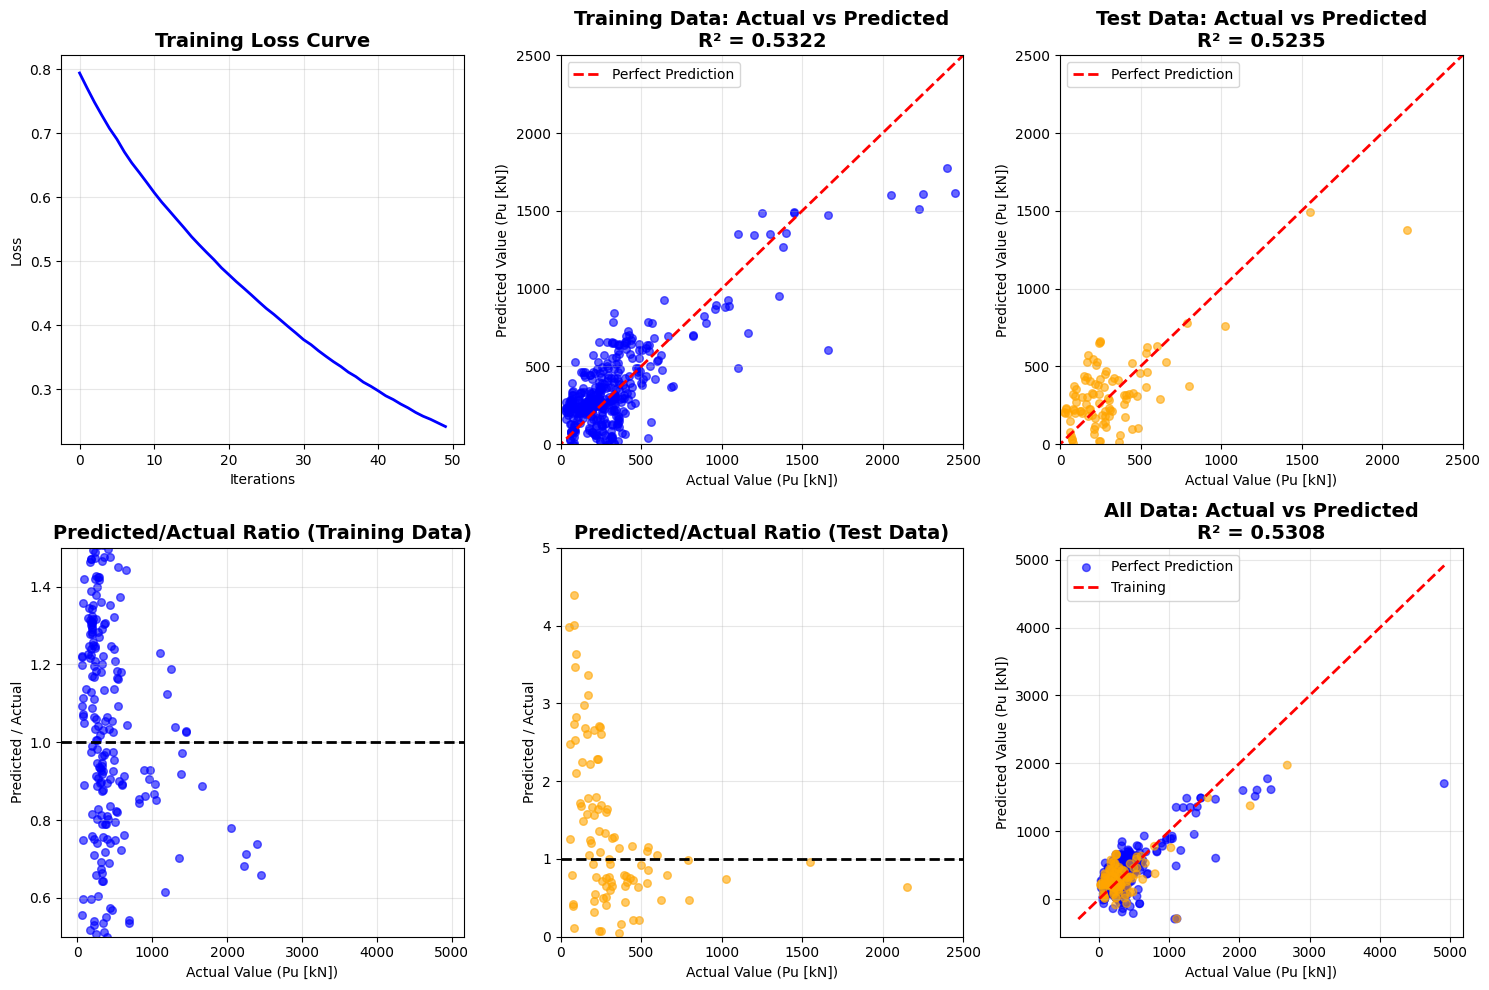


=== 입력 변수별 평균 가중치 크기 ===
h [mm]: 0.2710
b1 [mm]: 0.2897
fy [MPa]: 0.2248
davg [(mm)]: 0.4060
ravg: 0.2728
f1c [(MPa)]: 0.3933

=== 전체 데이터 성능 ===
전체 R²: 0.5308
전체 RMSE: 275.86 kN

모델과 스케일러가 'ann_punching_model.pkl'로 저장되었습니다.

=== 새로운 데이터 예측 예제 ===
입력: h=200mm, b1=300mm, fy=400MPa, davg=180mm, ravg=0.01, f1c=30MPa
예측된 펀칭 전단 강도: 496.12 kN


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
import seaborn as sns
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# Windows의 경우 맑은 고딕 사용 시도
try:
    # Windows 시스템 폰트 경로에서 맑은 고딕 찾기
    font_path = 'C:/Windows/Fonts/malgun.ttf'  # 맑은 고딕
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
except:
    # 맑은 고딕이 없으면 기본 설정 유지하고 영어로 표시
    print("한글 폰트를 찾을 수 없어 영어로 표시됩니다.")

# 데이터 로드
df = pd.read_excel("../데이터 베이스/Tran and Kim (2021).xlsx", sheet_name='NEES_Database__ACI_445_Punching')

# 데이터 확인
print("데이터 형태:", df.shape)
print("\n데이터 컬럼:", df.columns.tolist())
print("\n데이터 기본 통계:")
print(df.describe())

# 입력 변수와 출력 변수 정의
input_features = ['h [mm]', 'b1 [mm]', 'fy [MPa]', 'davg [(mm)]', 'ravg', 'f1c [(MPa)]']
output_feature = 'Pu [kN]'

# 결측값 확인 및 제거
print(f"\n결측값 개수:\n{df[input_features + [output_feature]].isnull().sum()}")
df_clean = df[input_features + [output_feature]].dropna()

# 특성과 타겟 분리
X = df_clean[input_features].values
y = df_clean[output_feature].values

print(f"\n정제된 데이터 개수: {len(X)}개")

# 데이터 분할 (훈련:테스트 = 80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"훈련 데이터: {len(X_train)}개")
print(f"테스트 데이터: {len(X_test)}개")

# 데이터 정규화
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# MLPRegressor 모델 생성
model = MLPRegressor(
    hidden_layer_sizes=(10,),  # 간단한 구조: 10개 뉴런 1개 은닉층
    activation='relu',
    solver='adam',
    alpha=0.001,  # 정규화 파라미터
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=50,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    verbose=True
)

# 모델 훈련
print("\n모델 훈련 시작...")
model.fit(X_train_scaled, y_train_scaled)

# 예측 수행
y_train_pred_scaled = model.predict(X_train_scaled)
y_test_pred_scaled = model.predict(X_test_scaled)

# 정규화 해제
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

# 성능 평가
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n=== 성능 평가 결과 ===")
print(f"훈련 데이터 - R²: {r2_train:.4f}, RMSE: {rmse_train:.2f}")
print(f"테스트 데이터 - R²: {r2_test:.4f}, RMSE: {rmse_test:.2f}")

# 모델 정보 출력
print(f"\n=== 모델 정보 ===")
print(f"최종 반복 횟수: {model.n_iter_}")
print(f"최종 손실: {model.loss_:.6f}")

# 시각화
plt.style.use('default')
fig = plt.figure(figsize=(15, 10))

# 1. 훈련 과정 시각화 (손실 곡선)
plt.subplot(2, 3, 1)
plt.plot(model.loss_curve_, linewidth=2, color='blue')
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# 2. 1:1 그래프 (훈련 데이터)
plt.subplot(2, 3, 2)
plt.scatter(y_train, y_train_pred, alpha=0.6, color='blue', s=30)
min_val = min(min(y_train), min(y_train_pred))
max_val = max(max(y_train), max(y_train_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted Value (Pu [kN])')
plt.title(f'Training Data: Actual vs Predicted\nR² = {r2_train:.4f}', fontsize=14, fontweight='bold')
plt.xlim(0, 2500)
plt.ylim(0, 2500)
plt.legend()
plt.grid(True, alpha=0.3)

# 3. 1:1 그래프 (테스트 데이터)
plt.subplot(2, 3, 3)
plt.scatter(y_test, y_test_pred, alpha=0.6, color='orange', s=30)
min_val = min(min(y_test), min(y_test_pred))
max_val = max(max(y_test), max(y_test_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted Value (Pu [kN])')
plt.title(f'Test Data: Actual vs Predicted\nR² = {r2_test:.4f}', fontsize=14, fontweight='bold')
plt.xlim(0, 2500)
plt.ylim(0, 2500)
plt.legend()
plt.grid(True, alpha=0.3)

# 4. 예측값/실제값 비율 플롯 (훈련 데이터)
plt.subplot(2, 3, 4)
ratio_train = y_train_pred / y_train
plt.scatter(y_train, ratio_train, alpha=0.6, color='blue', s=30)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted / Actual')
plt.title('Predicted/Actual Ratio (Training Data)', fontsize=14, fontweight='bold')
plt.ylim(0.5, 1.5)
plt.grid(True, alpha=0.3)

# 5. 예측값/실제값 비율 플롯 (테스트 데이터)
plt.subplot(2, 3, 5)
ratio_test = y_test_pred / y_test
plt.scatter(y_test, ratio_test, alpha=0.6, color='orange', s=30)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted / Actual')
plt.title('Predicted/Actual Ratio (Test Data)', fontsize=14, fontweight='bold')
plt.ylim(0, 5)
plt.xlim(0, 2500)
plt.grid(True, alpha=0.3)

# 6. 전체 데이터 1:1 그래프
plt.subplot(2, 3, 6)
# 전체 데이터 결합
y_all = np.concatenate([y_train, y_test])
y_all_pred = np.concatenate([y_train_pred, y_test_pred])
colors = ['blue'] * len(y_train) + ['orange'] * len(y_test)

plt.scatter(y_all, y_all_pred, alpha=0.6, c=colors, s=30)
min_val = min(min(y_all), min(y_all_pred))
max_val = max(max(y_all), max(y_all_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted Value (Pu [kN])')

# 전체 데이터 R² 계산
r2_all = r2_score(y_all, y_all_pred)
plt.title(f'All Data: Actual vs Predicted\nR² = {r2_all:.4f}', fontsize=14, fontweight='bold')
plt.legend(['Perfect Prediction', 'Training', 'Test'])
plt.grid(True, alpha=0.3)
plt.savefig("ANN_Model_Results 2.pdf", format="pdf", bbox_inches="tight", dpi=300)
print("\n그래프가 'ANN_Model_Results.pdf'로 저장되었습니다.")
plt.tight_layout()
plt.show()

# 특성 중요도 분석 (첫 번째 은닉층 가중치 기반)
print("\n=== 입력 변수별 평균 가중치 크기 ===")
if hasattr(model, 'coefs_') and len(model.coefs_) > 0:
    first_layer_weights = model.coefs_[0]  # 첫 번째 레이어의 가중치
    feature_importance = np.mean(np.abs(first_layer_weights), axis=1)
    
    for i, feature in enumerate(input_features):
        print(f"{feature}: {feature_importance[i]:.4f}")

# 전체 데이터 성능
rmse_all = np.sqrt(mean_squared_error(y_all, y_all_pred))

print(f"\n=== 전체 데이터 성능 ===")
print(f"전체 R²: {r2_all:.4f}")
print(f"전체 RMSE: {rmse_all:.2f} kN")

# 모델 저장 (pickle 사용)
import pickle

# 모델과 스케일러를 함께 저장
model_data = {
    'model': model,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'input_features': input_features
}

with open('ann_punching_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("\n모델과 스케일러가 'ann_punching_model.pkl'로 저장되었습니다.")

# 새로운 데이터 예측 예제 함수
def predict_new_data(h, b1, fy, davg, ravg, f1c):
    """새로운 데이터에 대한 펀칭 전단 강도 예측"""
    # 입력 데이터를 배열로 변환
    new_data = np.array([[h, b1, fy, davg, ravg, f1c]])
    
    # 정규화
    new_data_scaled = scaler_X.transform(new_data)
    
    # 예측
    pred_scaled = model.predict(new_data_scaled)
    
    # 정규화 해제
    pred = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))[0, 0]
    
    return pred

# 예측 함수 사용 예제
print("\n=== 새로운 데이터 예측 예제 ===")
example_h = 200  # mm
example_b1 = 300  # mm  
example_fy = 400  # MPa
example_davg = 180  # mm
example_ravg = 0.01
example_f1c = 30  # MPa

predicted_pu = predict_new_data(example_h, example_b1, example_fy, example_davg, example_ravg, example_f1c)
print(f"입력: h={example_h}mm, b1={example_b1}mm, fy={example_fy}MPa, davg={example_davg}mm, ravg={example_ravg}, f1c={example_f1c}MPa")
print(f"예측된 펀칭 전단 강도: {predicted_pu:.2f} kN")

### 3

데이터 형태: (510, 9)

데이터 컬럼: ['TestID', 'Authors', 'h [mm]', 'b1 [mm]', 'fy [MPa]', 'davg [(mm)]', 'ravg', 'f1c [(MPa)]', 'Pu [kN]']

데이터 기본 통계:
           TestID      h [mm]     b1 [mm]    fy [MPa]  davg [(mm)]  \
count  510.000000  510.000000  510.000000  510.000000   510.000000   
mean   256.452941  133.843137  192.674510  463.062745   107.720239   
std    148.864295   67.529539  102.365269  114.150919    60.640272   
min      1.000000   38.000000   51.000000  255.000000    29.972000   
25%    128.250000  100.500000  120.000000  374.500000    78.250000   
50%    255.500000  130.000000  160.000000  462.000000   107.000000   
75%    382.750000  152.000000  250.000000  531.000000   121.000000   
max    519.000000  730.000000  901.000000  749.000000   668.500000   

             ravg  f1c [(MPa)]      Pu [kN]  
count  510.000000   510.000000   510.000000  
mean     0.010982    32.720555   344.447059  
std      0.008230    17.724100   403.105509  
min      0.000000     8.662000    24.000000

c:\Users\yjy98\Documents\Punching-shear\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (75) reached and the optimization hasn't converged yet.
  warnings.warn(



그래프가 'ANN_Model_Results.pdf'로 저장되었습니다.


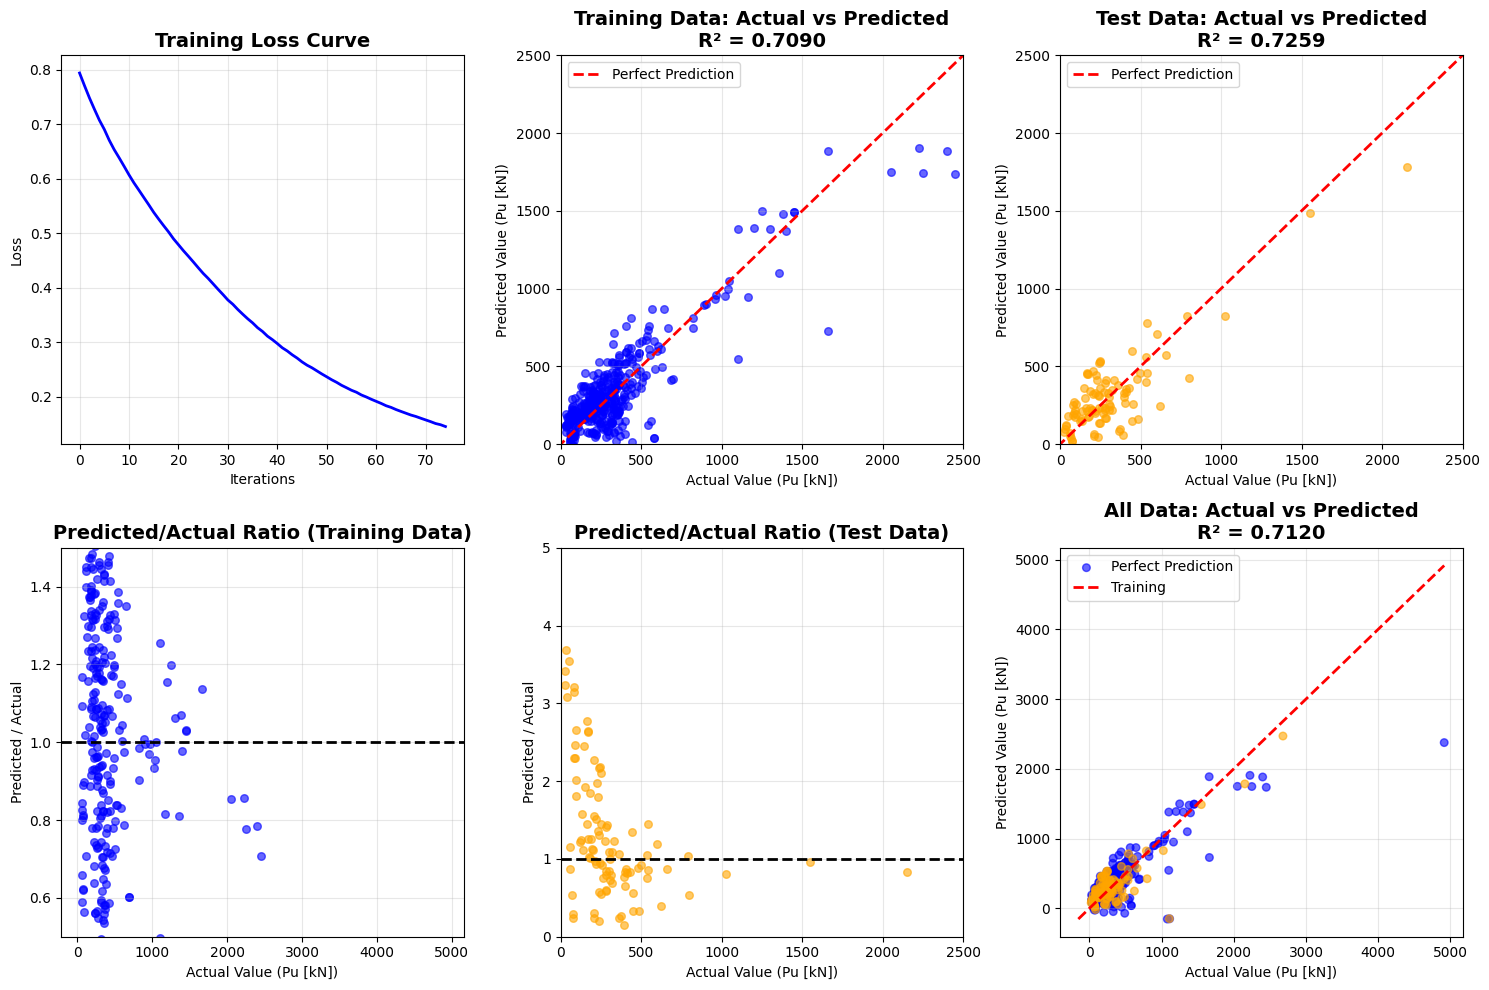


=== 입력 변수별 평균 가중치 크기 ===
h [mm]: 0.2538
b1 [mm]: 0.2765
fy [MPa]: 0.2158
davg [(mm)]: 0.4208
ravg: 0.2744
f1c [(MPa)]: 0.3840

=== 전체 데이터 성능 ===
전체 R²: 0.7120
전체 RMSE: 216.13 kN

모델과 스케일러가 'ann_punching_model.pkl'로 저장되었습니다.

=== 새로운 데이터 예측 예제 ===
입력: h=200mm, b1=300mm, fy=400MPa, davg=180mm, ravg=0.01, f1c=30MPa
예측된 펀칭 전단 강도: 630.45 kN


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
import seaborn as sns
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# Windows의 경우 맑은 고딕 사용 시도
try:
    # Windows 시스템 폰트 경로에서 맑은 고딕 찾기
    font_path = 'C:/Windows/Fonts/malgun.ttf'  # 맑은 고딕
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
except:
    # 맑은 고딕이 없으면 기본 설정 유지하고 영어로 표시
    print("한글 폰트를 찾을 수 없어 영어로 표시됩니다.")

# 데이터 로드
df = pd.read_excel("../데이터 베이스/Tran and Kim (2021).xlsx", sheet_name='NEES_Database__ACI_445_Punching')

# 데이터 확인
print("데이터 형태:", df.shape)
print("\n데이터 컬럼:", df.columns.tolist())
print("\n데이터 기본 통계:")
print(df.describe())

# 입력 변수와 출력 변수 정의
input_features = ['h [mm]', 'b1 [mm]', 'fy [MPa]', 'davg [(mm)]', 'ravg', 'f1c [(MPa)]']
output_feature = 'Pu [kN]'

# 결측값 확인 및 제거
print(f"\n결측값 개수:\n{df[input_features + [output_feature]].isnull().sum()}")
df_clean = df[input_features + [output_feature]].dropna()

# 특성과 타겟 분리
X = df_clean[input_features].values
y = df_clean[output_feature].values

print(f"\n정제된 데이터 개수: {len(X)}개")

# 데이터 분할 (훈련:테스트 = 80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"훈련 데이터: {len(X_train)}개")
print(f"테스트 데이터: {len(X_test)}개")

# 데이터 정규화
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# MLPRegressor 모델 생성
model = MLPRegressor(
    hidden_layer_sizes=(10,),  # 간단한 구조: 10개 뉴런 1개 은닉층
    activation='relu',
    solver='adam',
    alpha=0.001,  # 정규화 파라미터
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=75,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    verbose=True
)

# 모델 훈련
print("\n모델 훈련 시작...")
model.fit(X_train_scaled, y_train_scaled)

# 예측 수행
y_train_pred_scaled = model.predict(X_train_scaled)
y_test_pred_scaled = model.predict(X_test_scaled)

# 정규화 해제
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

# 성능 평가
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n=== 성능 평가 결과 ===")
print(f"훈련 데이터 - R²: {r2_train:.4f}, RMSE: {rmse_train:.2f}")
print(f"테스트 데이터 - R²: {r2_test:.4f}, RMSE: {rmse_test:.2f}")

# 모델 정보 출력
print(f"\n=== 모델 정보 ===")
print(f"최종 반복 횟수: {model.n_iter_}")
print(f"최종 손실: {model.loss_:.6f}")

# 시각화
plt.style.use('default')
fig = plt.figure(figsize=(15, 10))

# 1. 훈련 과정 시각화 (손실 곡선)
plt.subplot(2, 3, 1)
plt.plot(model.loss_curve_, linewidth=2, color='blue')
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# 2. 1:1 그래프 (훈련 데이터)
plt.subplot(2, 3, 2)
plt.scatter(y_train, y_train_pred, alpha=0.6, color='blue', s=30)
min_val = min(min(y_train), min(y_train_pred))
max_val = max(max(y_train), max(y_train_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted Value (Pu [kN])')
plt.title(f'Training Data: Actual vs Predicted\nR² = {r2_train:.4f}', fontsize=14, fontweight='bold')
plt.xlim(0, 2500)
plt.ylim(0, 2500)
plt.legend()
plt.grid(True, alpha=0.3)

# 3. 1:1 그래프 (테스트 데이터)
plt.subplot(2, 3, 3)
plt.scatter(y_test, y_test_pred, alpha=0.6, color='orange', s=30)
min_val = min(min(y_test), min(y_test_pred))
max_val = max(max(y_test), max(y_test_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted Value (Pu [kN])')
plt.title(f'Test Data: Actual vs Predicted\nR² = {r2_test:.4f}', fontsize=14, fontweight='bold')
plt.xlim(0, 2500)
plt.ylim(0, 2500)
plt.legend()
plt.grid(True, alpha=0.3)

# 4. 예측값/실제값 비율 플롯 (훈련 데이터)
plt.subplot(2, 3, 4)
ratio_train = y_train_pred / y_train
plt.scatter(y_train, ratio_train, alpha=0.6, color='blue', s=30)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted / Actual')
plt.title('Predicted/Actual Ratio (Training Data)', fontsize=14, fontweight='bold')
plt.ylim(0.5, 1.5)
plt.grid(True, alpha=0.3)

# 5. 예측값/실제값 비율 플롯 (테스트 데이터)
plt.subplot(2, 3, 5)
ratio_test = y_test_pred / y_test
plt.scatter(y_test, ratio_test, alpha=0.6, color='orange', s=30)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted / Actual')
plt.title('Predicted/Actual Ratio (Test Data)', fontsize=14, fontweight='bold')
plt.ylim(0, 5)
plt.xlim(0, 2500)
plt.grid(True, alpha=0.3)

# 6. 전체 데이터 1:1 그래프
plt.subplot(2, 3, 6)
# 전체 데이터 결합
y_all = np.concatenate([y_train, y_test])
y_all_pred = np.concatenate([y_train_pred, y_test_pred])
colors = ['blue'] * len(y_train) + ['orange'] * len(y_test)

plt.scatter(y_all, y_all_pred, alpha=0.6, c=colors, s=30)
min_val = min(min(y_all), min(y_all_pred))
max_val = max(max(y_all), max(y_all_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Value (Pu [kN])')
plt.ylabel('Predicted Value (Pu [kN])')

# 전체 데이터 R² 계산
r2_all = r2_score(y_all, y_all_pred)
plt.title(f'All Data: Actual vs Predicted\nR² = {r2_all:.4f}', fontsize=14, fontweight='bold')
plt.legend(['Perfect Prediction', 'Training', 'Test'])
plt.grid(True, alpha=0.3)
plt.savefig("ANN_Model_Results 3.pdf", format="pdf", bbox_inches="tight", dpi=300)
print("\n그래프가 'ANN_Model_Results.pdf'로 저장되었습니다.")
plt.tight_layout()
plt.show()

# 특성 중요도 분석 (첫 번째 은닉층 가중치 기반)
print("\n=== 입력 변수별 평균 가중치 크기 ===")
if hasattr(model, 'coefs_') and len(model.coefs_) > 0:
    first_layer_weights = model.coefs_[0]  # 첫 번째 레이어의 가중치
    feature_importance = np.mean(np.abs(first_layer_weights), axis=1)
    
    for i, feature in enumerate(input_features):
        print(f"{feature}: {feature_importance[i]:.4f}")

# 전체 데이터 성능
rmse_all = np.sqrt(mean_squared_error(y_all, y_all_pred))

print(f"\n=== 전체 데이터 성능 ===")
print(f"전체 R²: {r2_all:.4f}")
print(f"전체 RMSE: {rmse_all:.2f} kN")

# 모델 저장 (pickle 사용)
import pickle

# 모델과 스케일러를 함께 저장
model_data = {
    'model': model,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'input_features': input_features
}

with open('ann_punching_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("\n모델과 스케일러가 'ann_punching_model.pkl'로 저장되었습니다.")

# 새로운 데이터 예측 예제 함수
def predict_new_data(h, b1, fy, davg, ravg, f1c):
    """새로운 데이터에 대한 펀칭 전단 강도 예측"""
    # 입력 데이터를 배열로 변환
    new_data = np.array([[h, b1, fy, davg, ravg, f1c]])
    
    # 정규화
    new_data_scaled = scaler_X.transform(new_data)
    
    # 예측
    pred_scaled = model.predict(new_data_scaled)
    
    # 정규화 해제
    pred = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))[0, 0]
    
    return pred

# 예측 함수 사용 예제
print("\n=== 새로운 데이터 예측 예제 ===")
example_h = 200  # mm
example_b1 = 300  # mm  
example_fy = 400  # MPa
example_davg = 180  # mm
example_ravg = 0.01
example_f1c = 30  # MPa

predicted_pu = predict_new_data(example_h, example_b1, example_fy, example_davg, example_ravg, example_f1c)
print(f"입력: h={example_h}mm, b1={example_b1}mm, fy={example_fy}MPa, davg={example_davg}mm, ravg={example_ravg}, f1c={example_f1c}MPa")
print(f"예측된 펀칭 전단 강도: {predicted_pu:.2f} kN")